# Risk Parity Portfolio

In this notebook, we construct a Risk Parity portfolio using the same assets from the previous analyses.

Unlike traditional portfolios, Risk Parity focuses on balancing each asset's contribution to total portfolio risk.

The objective is to compare:

- Equal Weight Portfolio
- Balanced Portfolio
- Risk Parity Portfolio

We analyze portfolio weights, risk contributions, annualized return, volatility, Sharpe Ratio, and maximum drawdown.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Project folders
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
IMAGES_DIR = PROJECT_ROOT / "images"

OUTPUTS_DIR.mkdir(exist_ok=True)
IMAGES_DIR.mkdir(exist_ok=True)

# Load daily returns
returns = pd.read_csv(
    DATA_DIR / "daily_returns.csv",
    index_col=0,
    parse_dates=True
)

returns.head()

,GLD,QQQ,SPY,TLT
Date,,,,
2018-01-03,-0.002637,0.009717,0.006325,0.004782
2018-01-04,0.005127,0.001749,0.004215,-0.000159
2018-01-05,-0.001036,0.010043,0.006664,-0.002856
2018-01-08,-0.000160,0.003891,0.001829,-0.000637
2018-01-09,-0.004628,0.000062,0.002264,-0.013372


In [2]:
# Basic inputs
assets = returns.columns
n_assets = len(assets)

trading_days = 252
risk_free_rate = 0.00
initial_portfolio_value = 10_000

mean_daily_returns = returns.mean()
cov_daily_matrix = returns.cov()
cov_annual_matrix = cov_daily_matrix * trading_days

print("Assets:")
print(list(assets))
print(f"Number of assets: {n_assets}")

Assets:
['GLD', 'QQQ', 'SPY', 'TLT']
Number of assets: 4


## Risk Contribution Calculation

Risk contribution measures how much each asset contributes to the total volatility of the portfolio.

In a Risk Parity portfolio, the objective is to make these contributions as equal as possible.

In [3]:
def portfolio_volatility(weights, cov_matrix):
    """
    Calculates portfolio volatility.
    """
    return np.sqrt(weights.T @ cov_matrix @ weights)


def risk_contributions(weights, cov_matrix):
    """
    Calculates each asset's percentage contribution to total portfolio risk.
    """
    portfolio_vol = portfolio_volatility(weights, cov_matrix)

    marginal_contribution = cov_matrix @ weights
    absolute_risk_contribution = weights * marginal_contribution / portfolio_vol
    percentage_risk_contribution = absolute_risk_contribution / portfolio_vol

    return percentage_risk_contribution


def risk_parity_objective(weights, cov_matrix):
    """
    Objective function: minimize the difference between actual risk contributions
    and equal risk contributions.
    """
    target_risk_contribution = np.ones(len(weights)) / len(weights)
    actual_risk_contribution = risk_contributions(weights, cov_matrix)

    return np.sum((actual_risk_contribution - target_risk_contribution) ** 2)

In [4]:
# Initial guess: equal weights
initial_guess = np.ones(n_assets) / n_assets

# Constraints: weights must sum to 1
constraints = (
    {
        "type": "eq",
        "fun": lambda weights: np.sum(weights) - 1
    },
)

# Bounds: long-only portfolio, no short selling
bounds = tuple((0, 1) for _ in range(n_assets))

# Optimization
risk_parity_solution = minimize(
    fun=risk_parity_objective,
    x0=initial_guess,
    args=(cov_annual_matrix,),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

risk_parity_weights = pd.Series(
    risk_parity_solution.x,
    index=assets,
    name="Risk Parity"
)

risk_parity_weights

GLD    0.269773
QQQ    0.163727
SPY    0.212473
TLT    0.354027
Name: Risk Parity, dtype: float64

In [5]:
# Define comparison portfolios
equal_weight = pd.Series(
    np.ones(n_assets) / n_assets,
    index=assets,
    name="Equal Weight"
)

balanced_weight = pd.Series(
    {
        "SPY": 0.40,
        "QQQ": 0.30,
        "TLT": 0.20,
        "GLD": 0.10
    }
)

balanced_weight = balanced_weight[assets]
balanced_weight.name = "Balanced"

weights_comparison = pd.DataFrame({
    "Equal Weight": equal_weight,
    "Balanced": balanced_weight,
    "Risk Parity": risk_parity_weights
})

# Save results
weights_comparison.to_csv(
    OUTPUTS_DIR / "risk_parity_weights_comparison.csv"
)

weights_comparison

,Equal Weight,Balanced,Risk Parity
GLD,0.25,0.1,0.269773
QQQ,0.25,0.3,0.163727
SPY,0.25,0.4,0.212473
TLT,0.25,0.2,0.354027


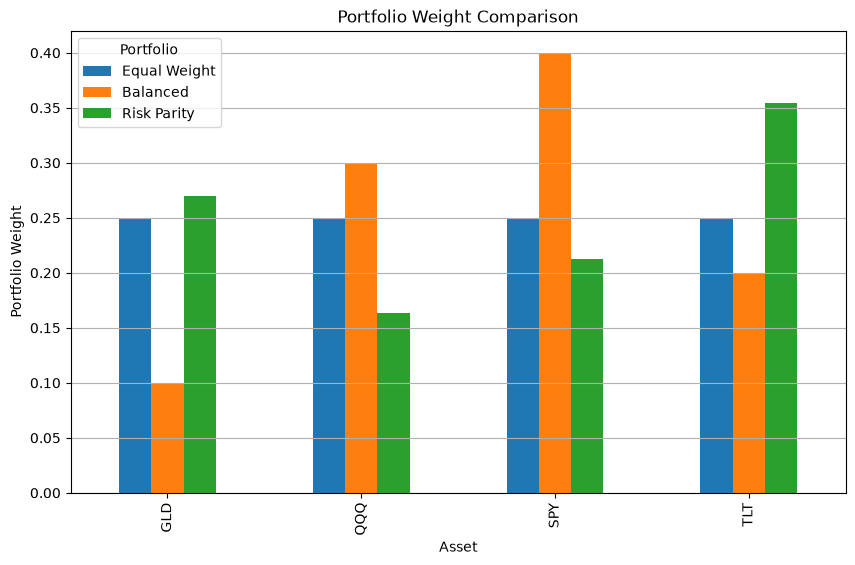

In [6]:
ax = weights_comparison.plot(kind="bar", figsize=(10, 6))

plt.title("Portfolio Weight Comparison")
plt.xlabel("Asset")
plt.ylabel("Portfolio Weight")
plt.grid(axis="y")
plt.legend(title="Portfolio")

fig = ax.get_figure()
fig.savefig(IMAGES_DIR / "risk_parity_weights_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

In [7]:
risk_contribution_comparison = pd.DataFrame()

for portfolio_name in weights_comparison.columns:
    weights = weights_comparison[portfolio_name].values

    risk_contribution_comparison[portfolio_name] = risk_contributions(
        weights,
        cov_annual_matrix
    )

risk_contribution_comparison.index = assets

# Save results
risk_contribution_comparison.to_csv(
    OUTPUTS_DIR / "risk_contribution_comparison.csv"
)

risk_contribution_comparison

,Equal Weight,Balanced,Risk Parity
GLD,0.174414,0.031440,0.250106
QQQ,0.413125,0.458414,0.250063
SPY,0.321666,0.485639,0.249945
TLT,0.090795,0.024506,0.249886


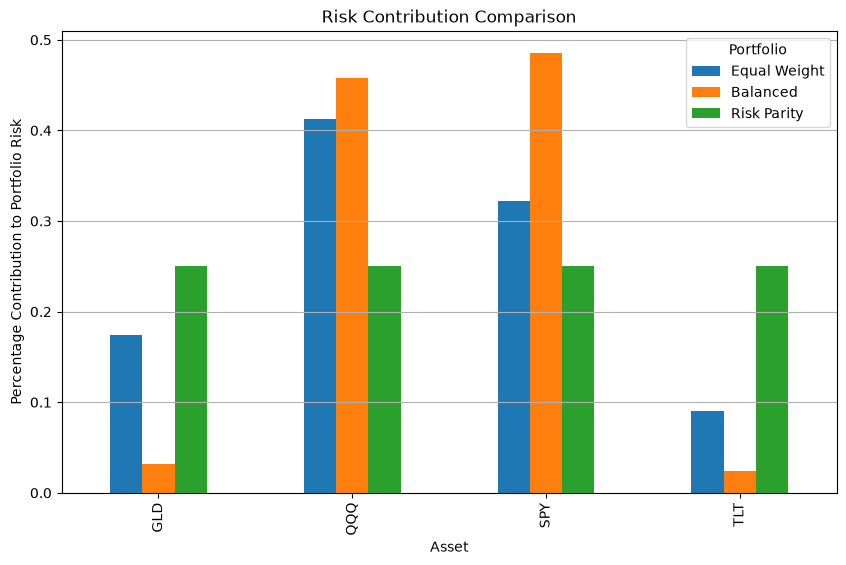

In [8]:
ax = risk_contribution_comparison.plot(kind="bar", figsize=(10, 6))

plt.title("Risk Contribution Comparison")
plt.xlabel("Asset")
plt.ylabel("Percentage Contribution to Portfolio Risk")
plt.grid(axis="y")
plt.legend(title="Portfolio")

fig = ax.get_figure()
fig.savefig(IMAGES_DIR / "risk_contribution_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

In [9]:
def calculate_portfolio_performance(weights, returns, risk_free_rate=0.00):
    """
    Calculates annualized return, volatility, Sharpe Ratio, and maximum drawdown.
    """
    portfolio_daily_returns = returns @ weights

    cumulative_values = initial_portfolio_value * (1 + portfolio_daily_returns).cumprod()

    annualized_return = portfolio_daily_returns.mean() * trading_days
    annualized_volatility = portfolio_daily_returns.std() * np.sqrt(trading_days)

    sharpe_ratio = (
        (annualized_return - risk_free_rate) / annualized_volatility
        if annualized_volatility != 0
        else np.nan
    )

    running_max = cumulative_values.cummax()
    drawdown = cumulative_values / running_max - 1
    max_drawdown = drawdown.min()

    final_value = cumulative_values.iloc[-1]

    return {
        "Final Value": final_value,
        "Annualized Return": annualized_return,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": max_drawdown
    }

In [10]:
performance_results = {}

for portfolio_name in weights_comparison.columns:
    weights = weights_comparison[portfolio_name].values

    performance_results[portfolio_name] = calculate_portfolio_performance(
        weights,
        returns,
        risk_free_rate=risk_free_rate
    )

risk_parity_performance_summary = pd.DataFrame(performance_results).T

# Save results
risk_parity_performance_summary.to_csv(
    OUTPUTS_DIR / "risk_parity_performance_summary.csv"
)

risk_parity_performance_summary

,Final Value,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
Equal Weight,27286.195039,0.126101,0.124146,1.015749,-0.251545
Balanced,29434.977963,0.138521,0.149518,0.926453,-0.273791
Risk Parity,22974.128845,0.104221,0.110616,0.942185,-0.253305


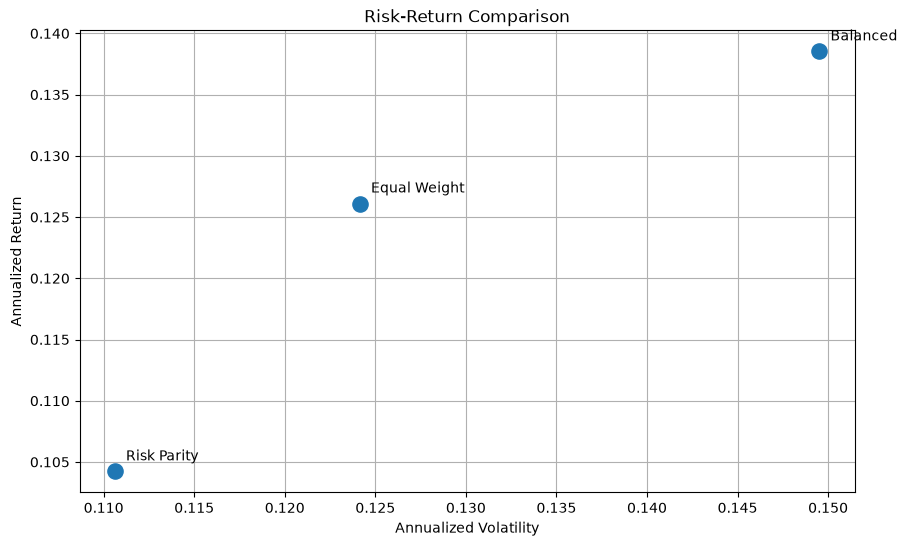

In [11]:
plt.figure(figsize=(10, 6))

plt.scatter(
    risk_parity_performance_summary["Annualized Volatility"],
    risk_parity_performance_summary["Annualized Return"],
    s=120
)

for portfolio_name in risk_parity_performance_summary.index:
    plt.annotate(
        portfolio_name,
        (
            risk_parity_performance_summary.loc[portfolio_name, "Annualized Volatility"],
            risk_parity_performance_summary.loc[portfolio_name, "Annualized Return"]
        ),
        textcoords="offset points",
        xytext=(8, 8)
    )

plt.title("Risk-Return Comparison")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.grid(True)

plt.savefig(IMAGES_DIR / "risk_parity_risk_return_comparison.png", dpi=300, bbox_inches="tight")

plt.show()

## Risk Parity Interpretation

The Risk Parity portfolio aims to balance the percentage contribution of each asset to total portfolio risk.

Compared with Equal Weight and Balanced portfolios, Risk Parity may assign lower capital weights to more volatile assets and higher weights to less volatile assets.

This approach can improve diversification from a risk perspective, because the portfolio is not dominated by the most volatile assets.

The results show that portfolio construction can be based not only on capital allocation, but also on how much each asset contributes to overall portfolio risk.